# MNIST Binary Classification - Logistic Regression

## Complete Pipeline: Data Loading → Preprocessing → Training → Evaluation

This notebook contains the complete end-to-end pipeline for Logistic Regression.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Configuration

In [2]:
# Binary classification configuration
DIGIT_A = 0
DIGIT_B = 1

# Data split configuration
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# PCA configuration
PCA_COMPONENTS = 50

# Logistic Regression hyperparameters
LEARNING_RATE = 0.01
N_ITERATIONS = 1000

print(f"Configuration:")
print(f"  Binary Classification: Digit {DIGIT_A} vs Digit {DIGIT_B}")
print(f"  Train/Val/Test Split: {TRAIN_SIZE:.0%}/{VAL_SIZE:.0%}/{TEST_SIZE:.0%}")
print(f"  PCA Components: {PCA_COMPONENTS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Iterations: {N_ITERATIONS}")

Configuration:
  Binary Classification: Digit 0 vs Digit 1
  Train/Val/Test Split: 70%/15%/15%
  PCA Components: 50
  Learning Rate: 0.01
  Iterations: 1000


## 3. Load Data

In [3]:
print("=" * 70)
print("LOADING DATA")
print("=" * 70)

# Load training data
X_train_raw = np.load('../mnist.npz/x_train.npy')
y_train_raw = np.load('../mnist.npz/y_train.npy')

# Load test data
X_test_raw = np.load('../mnist.npz/x_test.npy')
y_test_raw = np.load('../mnist.npz/y_test.npy')

print(f"Training data shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"Test data shape: X={X_test_raw.shape}, y={y_test_raw.shape}")
print("\n✓ Data loaded successfully")

LOADING DATA
Training data shape: X=(60000, 28, 28), y=(60000,)
Test data shape: X=(10000, 28, 28), y=(10000,)

✓ Data loaded successfully


## 4. Visualize Sample Images

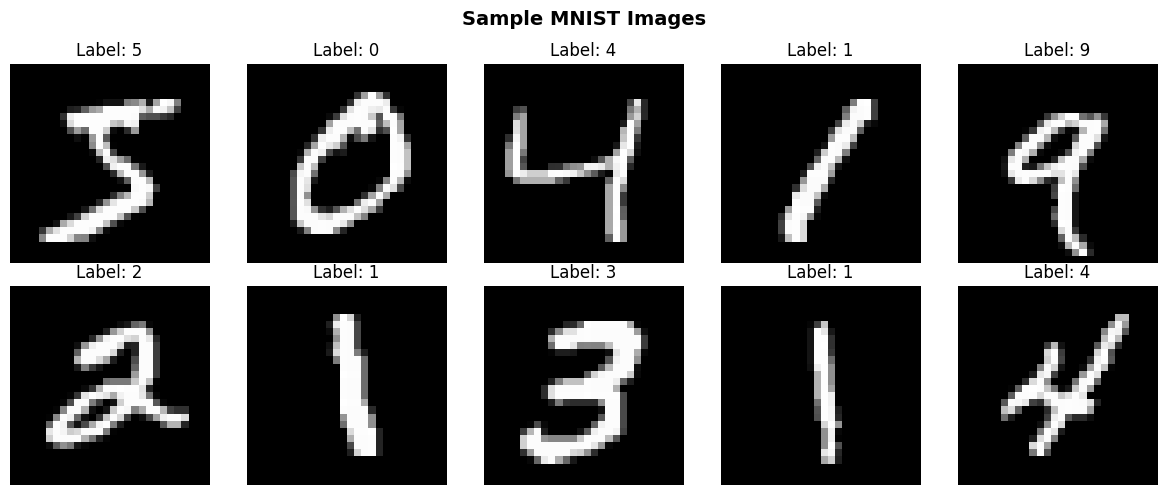

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_train_raw[i], cmap='gray')
    axes[i].set_title(f'Label: {y_train_raw[i]}')
    axes[i].axis('off')

plt.suptitle('Sample MNIST Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Filter Binary Classes

In [5]:
print("=" * 70)
print(f"FILTERING BINARY CLASSES: {DIGIT_A} vs {DIGIT_B}")
print("=" * 70)

# Filter training data
train_mask = (y_train_raw == DIGIT_A) | (y_train_raw == DIGIT_B)
X_train_filtered = X_train_raw[train_mask]
y_train_binary = (y_train_raw[train_mask] == DIGIT_B).astype(int)

print(f"Filtered training dataset size: {len(y_train_binary)}")
print(f"Class distribution: {DIGIT_A}={np.sum(y_train_binary == 0)}, {DIGIT_B}={np.sum(y_train_binary == 1)}")
print("\n✓ Binary classes filtered")

FILTERING BINARY CLASSES: 0 vs 1
Filtered training dataset size: 12665
Class distribution: 0=5923, 1=6742

✓ Binary classes filtered


## Visualise Binary Classes

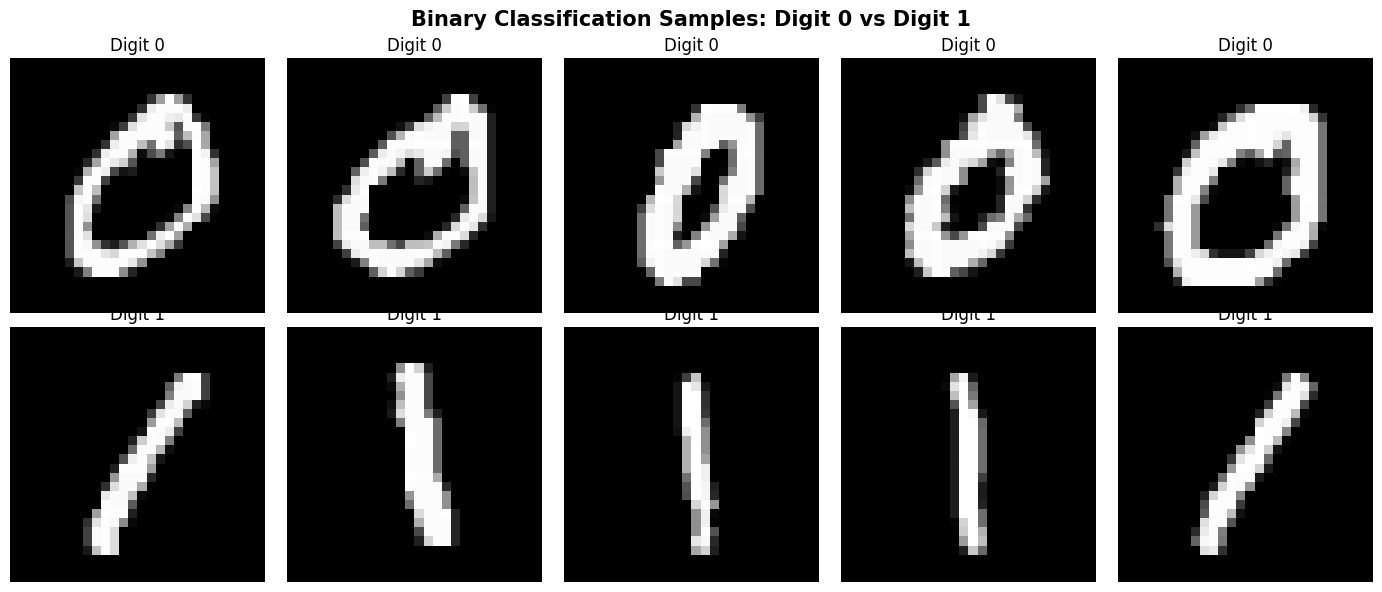

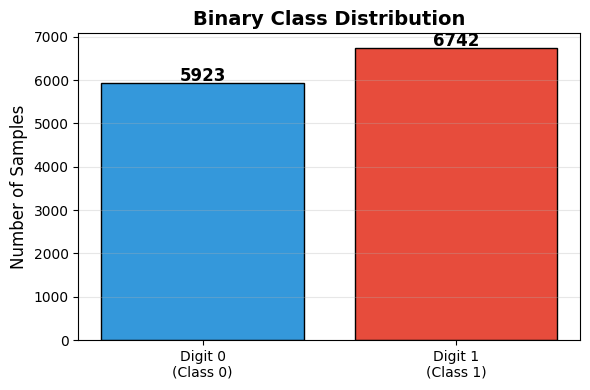

In [6]:
# ── Visualise the two binary classes chosen from the dataset ──────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

class0_idx = np.where(y_train_binary == 0)[0]
class1_idx = np.where(y_train_binary == 1)[0]

for i in range(5):
    axes[0, i].imshow(X_train_filtered[class0_idx[i]], cmap='gray')
    axes[0, i].set_title(f'Digit {DIGIT_A}', fontsize=12)
    axes[0, i].axis('off')

for i in range(5):
    axes[1, i].imshow(X_train_filtered[class1_idx[i]], cmap='gray')
    axes[1, i].set_title(f'Digit {DIGIT_B}', fontsize=12)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel(f'Class 0\n(Digit {DIGIT_A})', fontsize=12,
                       rotation=0, labelpad=60, va='center')
axes[1, 0].set_ylabel(f'Class 1\n(Digit {DIGIT_B})', fontsize=12,
                       rotation=0, labelpad=60, va='center')

plt.suptitle(f'Binary Classification Samples: Digit {DIGIT_A} vs Digit {DIGIT_B}',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Class-distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4))
counts = [np.sum(y_train_binary == 0), np.sum(y_train_binary == 1)]
bars = ax.bar([f'Digit {DIGIT_A}\n(Class 0)', f'Digit {DIGIT_B}\n(Class 1)'],
              counts, color=['#3498db', '#e74c3c'], edgecolor='black')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            str(c), ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Binary Class Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Split Data

In [8]:
print("=" * 70)
print("SPLITTING DATA")
print("=" * 70)

# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X_train_filtered, y_train_binary,
    test_size=TEST_SIZE / (TRAIN_SIZE + VAL_SIZE + TEST_SIZE),
    random_state=42,
    stratify=y_train_binary
)

# Second split: separate train and validation
val_size_adjusted = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_size_adjusted,
    random_state=42,
    stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print("\n✓ Data split completed")

SPLITTING DATA
Training set: 8865 samples
Validation set: 1900 samples
Test set: 1900 samples

✓ Data split completed


## 7. Preprocess Data

In [9]:
print("=" * 70)
print("PREPROCESSING DATA")
print("=" * 70)

# Step 1: Normalize pixel values
print("Step 1: Normalizing pixel values (0-255 -> 0-1)")
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

# Step 2: Flatten images
print("Step 2: Flattening images (28x28 -> 784)")
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_val_flat = X_val_norm.reshape(X_val_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

# Step 3: Standardize features
print("Step 3: Standardizing features")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

print(f"\n✓ Preprocessing completed")

PREPROCESSING DATA
Step 1: Normalizing pixel values (0-255 -> 0-1)
Step 2: Flattening images (28x28 -> 784)
Step 3: Standardizing features

✓ Preprocessing completed


## 8. Apply PCA

In [10]:
print("=" * 70)
print(f"APPLYING PCA (n_components={PCA_COMPONENTS})")
print("=" * 70)

pca = PCA(n_components=PCA_COMPONENTS)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Reduced features: {X_train_pca.shape[1]}")
print(f"Explained variance: {cumulative_variance[-1]:.4f}")
print("\n✓ PCA applied")

APPLYING PCA (n_components=50)
Original features: 784
Reduced features: 50
Explained variance: 0.6842

✓ PCA applied


## Visualise Feature Extraction — Step 1: Flattening

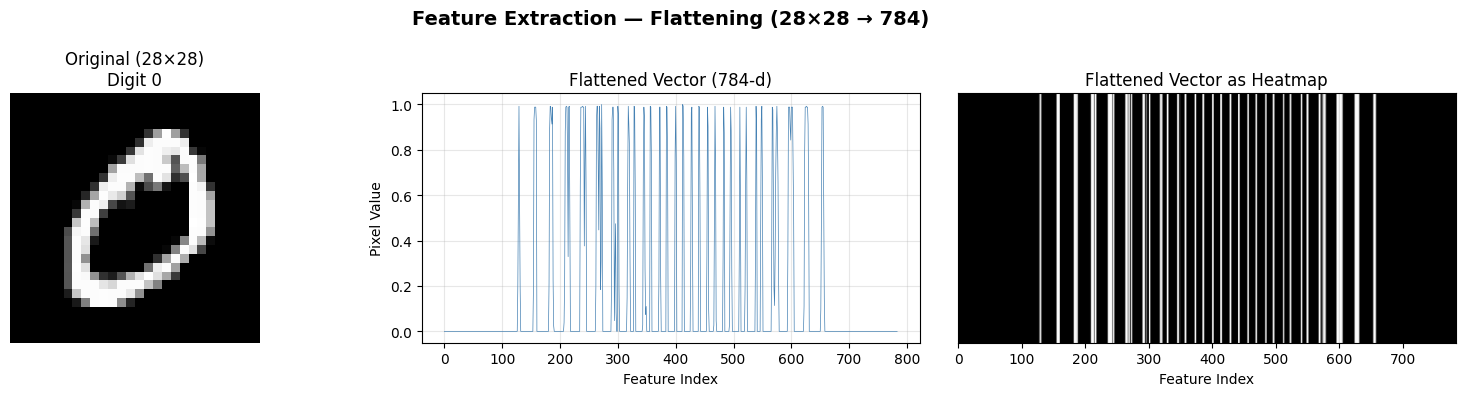

In [11]:
# ── Flattening visualisation ──────────────────────────────────────────
sample_img = X_train_filtered[0]
sample_label = DIGIT_A if y_train_binary[0] == 0 else DIGIT_B

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f'Original (28×28)\nDigit {sample_label}', fontsize=12)
axes[0].axis('off')

flat = sample_img.reshape(-1) / 255.0
axes[1].plot(flat, color='steelblue', linewidth=0.5)
axes[1].set_title('Flattened Vector (784-d)', fontsize=12)
axes[1].set_xlabel('Feature Index'); axes[1].set_ylabel('Pixel Value')
axes[1].grid(True, alpha=0.3)

axes[2].imshow(flat.reshape(1, -1), cmap='gray', aspect='auto')
axes[2].set_title('Flattened Vector as Heatmap', fontsize=12)
axes[2].set_xlabel('Feature Index'); axes[2].set_yticks([])

plt.suptitle('Feature Extraction — Flattening (28×28 → 784)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Visualise Feature Extraction — Step 2: PCA

C:\Users\a7med\AppData\Local\Temp\ipykernel_23580\135121468.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


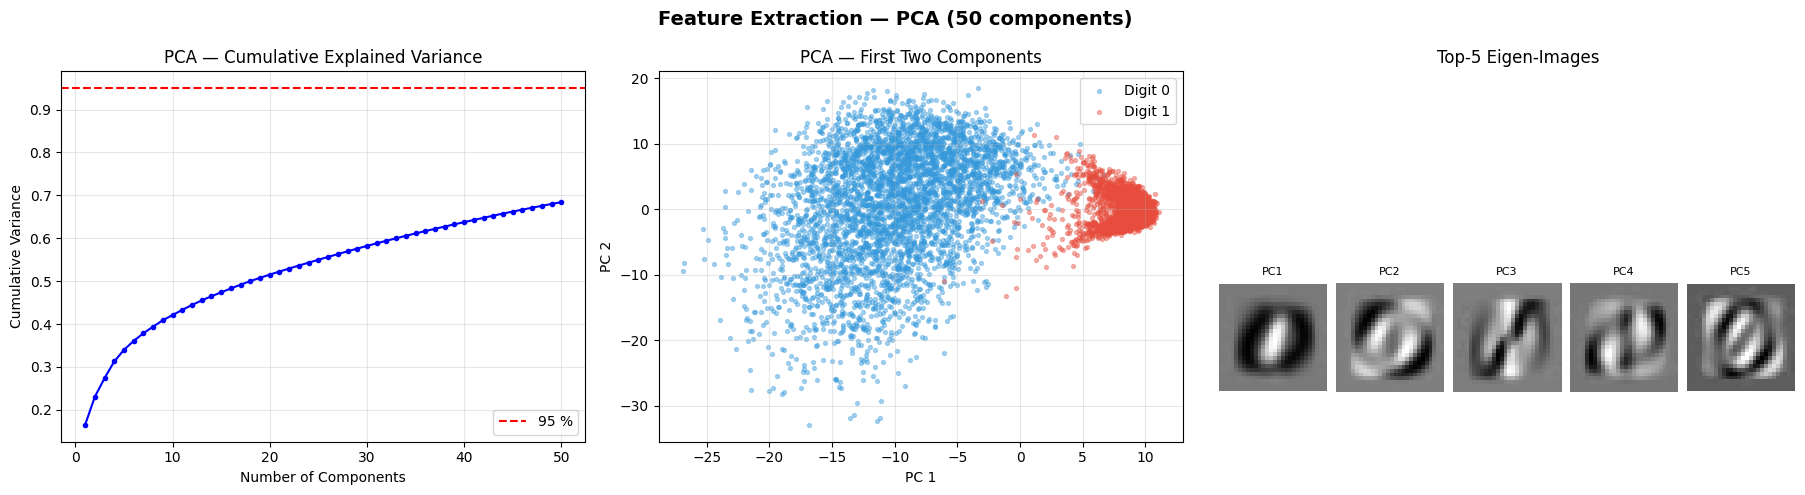

In [29]:
# ── PCA visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Cumulative explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'b-o', markersize=3)
axes[0].set_xlabel('Number of Components'); axes[0].set_ylabel('Cumulative Variance')
axes[0].set_title('PCA — Cumulative Explained Variance', fontsize=12)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='95 %')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 2) 2-D scatter of first two principal components
# Use X_train_pca (all training data after PCA) and y_train_binary as labels
scatter_x = X_train_pca[:, 0]
scatter_y = X_train_pca[:, 1]
scatter_labels = y_train  # available in all notebooks at this point
c0 = scatter_labels == 0; c1 = scatter_labels == 1
axes[1].scatter(scatter_x[c0], scatter_y[c0], alpha=0.4, s=8, label=f'Digit {DIGIT_A}', color='#3498db')
axes[1].scatter(scatter_x[c1], scatter_y[c1], alpha=0.4, s=8, label=f'Digit {DIGIT_B}', color='#e74c3c')
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')
axes[1].set_title('PCA — First Two Components', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# 3) Top-5 eigen-images (principal components reshaped back to 28×28)
n_show = min(5, pca.n_components_)
for k in range(n_show):
    ax_inset = fig.add_axes([0.68 + k*0.065, 0.15, 0.06, 0.35])
    ax_inset.imshow(pca.components_[k].reshape(28, 28), cmap='gray')
    ax_inset.set_title(f'PC{k+1}', fontsize=8); ax_inset.axis('off')
axes[2].axis('off')
axes[2].set_title('Top-5 Eigen-Images', fontsize=12)

plt.suptitle(f'Feature Extraction — PCA ({PCA_COMPONENTS} components)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Visualise Feature Extraction — Step 3: HOG (demonstration)

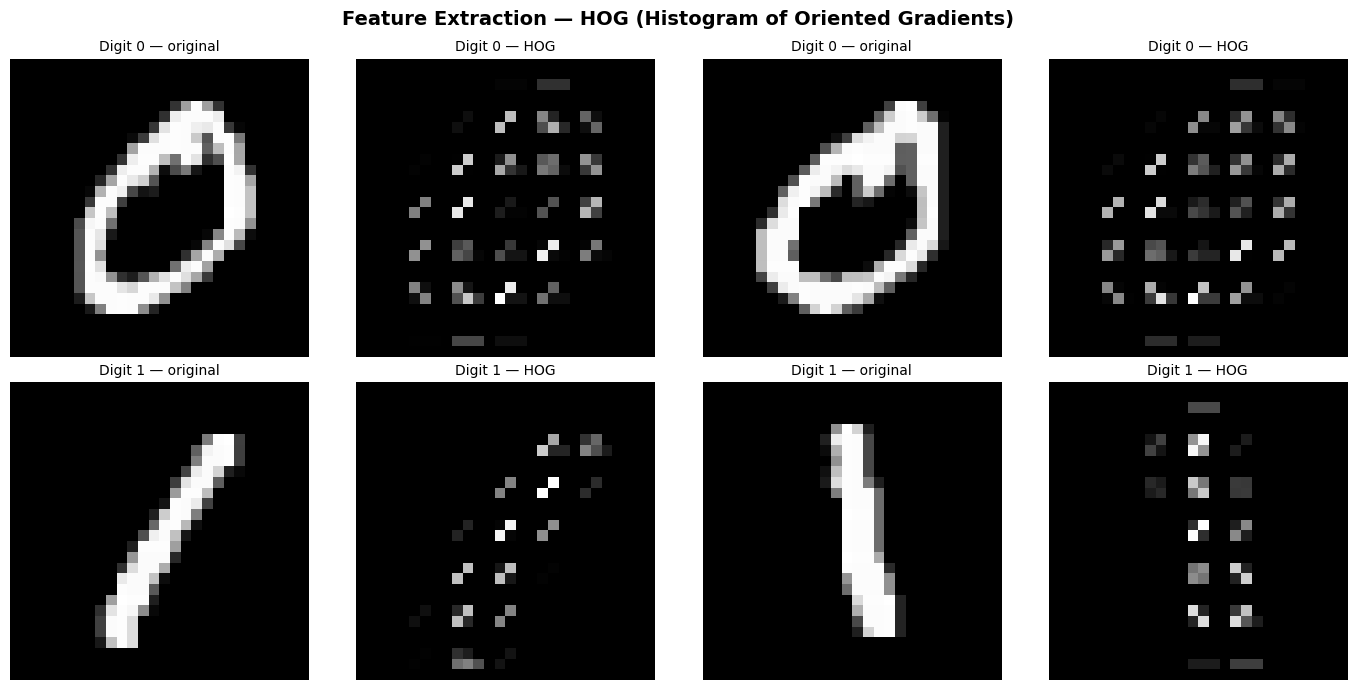

In [28]:
# ── HOG feature visualisation (demonstration) ────────────────────────
# HOG is not used in this pipeline but is shown here for comparison.
try:
    from skimage.feature import hog

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    class0_idx = np.where(y_train_binary == 0)[0]
    class1_idx = np.where(y_train_binary == 1)[0]

    for col, idx in enumerate([class0_idx[0], class0_idx[1]]):
        img = X_train_filtered[idx].astype(np.float64)
        _, hog_img = hog(img, orientations=9, pixels_per_cell=(4, 4),
                         cells_per_block=(2, 2), visualize=True)
        axes[0, col*2].imshow(img, cmap='gray')
        axes[0, col*2].set_title(f'Digit {DIGIT_A} — original', fontsize=10)
        axes[0, col*2].axis('off')
        axes[0, col*2+1].imshow(hog_img, cmap='gray')
        axes[0, col*2+1].set_title(f'Digit {DIGIT_A} — HOG', fontsize=10)
        axes[0, col*2+1].axis('off')

    for col, idx in enumerate([class1_idx[0], class1_idx[1]]):
        img = X_train_filtered[idx].astype(np.float64)
        _, hog_img = hog(img, orientations=9, pixels_per_cell=(4, 4),
                         cells_per_block=(2, 2), visualize=True)
        axes[1, col*2].imshow(img, cmap='gray')
        axes[1, col*2].set_title(f'Digit {DIGIT_B} — original', fontsize=10)
        axes[1, col*2].axis('off')
        axes[1, col*2+1].imshow(hog_img, cmap='gray')
        axes[1, col*2+1].set_title(f'Digit {DIGIT_B} — HOG', fontsize=10)
        axes[1, col*2+1].axis('off')

    plt.suptitle('Feature Extraction — HOG (Histogram of Oriented Gradients)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
except ImportError:
    print("⚠ scikit-image is not installed. Run: pip install scikit-image")

## 9. Logistic Regression Implementation

In [17]:
class LogisticRegressionScratch:
    """Logistic Regression implemented from scratch."""
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []
    
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for i in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)
            
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            if i % 100 == 0:
                loss = -np.mean(y * np.log(y_predicted + 1e-15) + 
                               (1 - y) * np.log(1 - y_predicted + 1e-15))
                self.losses.append(loss)
    
    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        return (y_predicted >= 0.5).astype(int)

print("✓ LogisticRegressionScratch class defined")

✓ LogisticRegressionScratch class defined


## 10. Train Model

In [18]:
print("=" * 70)
print("TRAINING LOGISTIC REGRESSION")
print("=" * 70)

model = LogisticRegressionScratch(learning_rate=LEARNING_RATE, n_iterations=N_ITERATIONS)
model.fit(X_train_pca, y_train)

print("\n✓ Training completed")

TRAINING LOGISTIC REGRESSION

✓ Training completed


## 11. Training Loss Curve

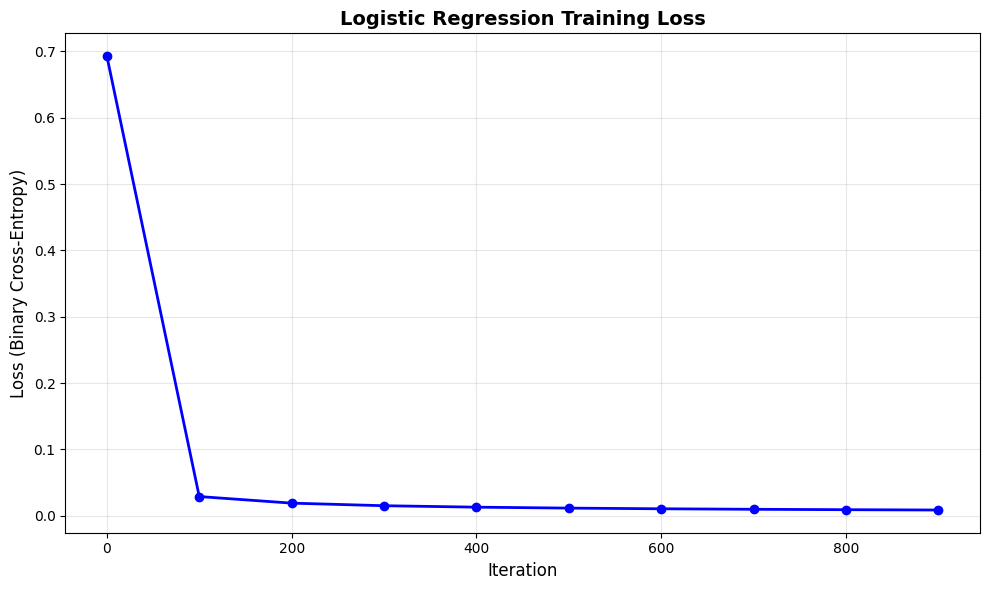

Initial Loss: 0.6931
Final Loss: 0.0086


In [19]:
plt.figure(figsize=(10, 6))
plt.plot(range(0, N_ITERATIONS, 100), model.losses, 'b-', linewidth=2, marker='o')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
plt.title('Logistic Regression Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial Loss: {model.losses[0]:.4f}")
print(f"Final Loss: {model.losses[-1]:.4f}")

## 12. Evaluate on All Sets

In [20]:
# Training set
train_pred = model.predict(X_train_pca)
train_acc = np.mean(train_pred == y_train)

# Validation set
val_pred = model.predict(X_val_pca)
val_acc = np.mean(val_pred == y_val)

# Test set
test_pred = model.predict(X_test_pca)
test_acc = np.mean(test_pred == y_test)

print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)
print(f"Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)")

MODEL PERFORMANCE
Training Accuracy:   0.9984 (99.84%)
Validation Accuracy: 0.9963 (99.63%)
Test Accuracy:       0.9974 (99.74%)


## 13. Detailed Metrics

In [21]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, test_pred)

# Calculate metrics
tp = cm[1, 1]
tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("=" * 70)
print("DETAILED METRICS (TEST SET)")
print("=" * 70)
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, test_pred, 
                           target_names=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}']))

DETAILED METRICS (TEST SET)
Accuracy:  0.9974
Precision: 0.9961
Recall:    0.9990
F1 Score:  0.9975

Classification Report:
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00       889
     Digit 1       1.00      1.00      1.00      1011

    accuracy                           1.00      1900
   macro avg       1.00      1.00      1.00      1900
weighted avg       1.00      1.00      1.00      1900



## 14. Confusion Matrix Visualization

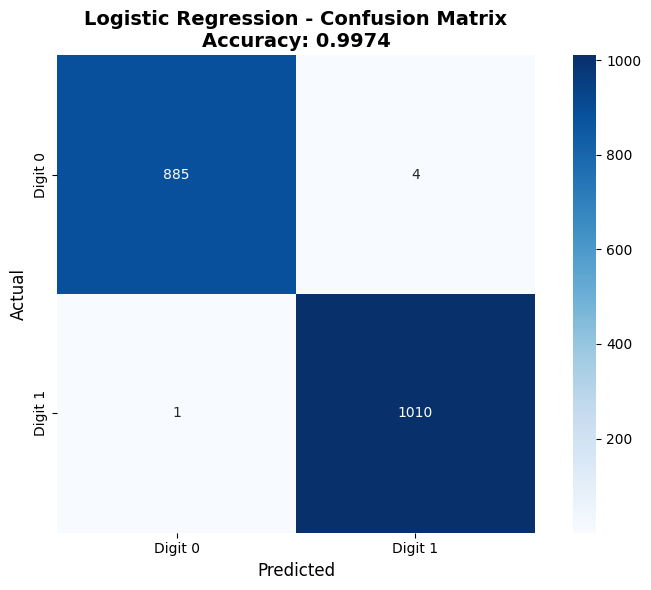

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'],
           yticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'],
           cbar=True, square=True)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.title(f'Logistic Regression - Confusion Matrix\nAccuracy: {test_acc:.4f}', 
         fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualise Misclassified Samples

Total misclassified: 5 out of 1900


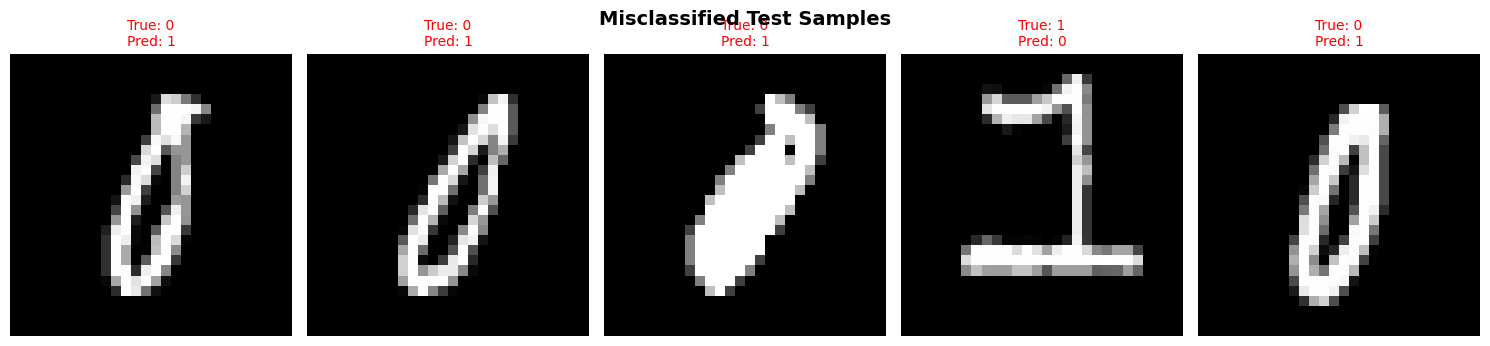

In [23]:
# ── Show wrongly classified test samples ──────────────────────────────
wrong_idx = np.where(test_pred != y_test)[0]
n_wrong = len(wrong_idx)
print(f"Total misclassified: {n_wrong} out of {len(y_test)}")

n_show = min(n_wrong, 20)
if n_show == 0:
    print("No misclassified samples — perfect accuracy!")
else:
    cols = min(n_show, 5)
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3.5*rows))
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]
    for k in range(n_show):
        r, c_col = divmod(k, cols)
        idx = wrong_idx[k]
        true_digit = DIGIT_A if y_test[idx] == 0 else DIGIT_B
        pred_digit = DIGIT_A if test_pred[idx] == 0 else DIGIT_B
        axes[r, c_col].imshow(X_test[idx], cmap='gray')
        axes[r, c_col].set_title(f'True: {true_digit}\nPred: {pred_digit}',
                                  fontsize=10, color='red')
        axes[r, c_col].axis('off')
    # hide unused axes
    for k in range(n_show, rows*cols):
        r, c_col = divmod(k, cols)
        axes[r, c_col].axis('off')
    plt.suptitle('Misclassified Test Samples', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

## 15. Summary

In [27]:
print("\n" + "=" * 70)
print("LOGISTIC REGRESSION - COMPLETE PIPELINE SUMMARY")
print("=" * 70)
print(f"\nConfiguration:")
print(f"  Digits: {DIGIT_A} vs {DIGIT_B}")
print(f"  PCA Components: {PCA_COMPONENTS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Iterations: {N_ITERATIONS}")
print(f"\nDataset:")
print(f"  Training: {len(y_train)} samples")
print(f"  Validation: {len(y_val)} samples")
print(f"  Test: {len(y_test)} samples")
print(f"\nFinal Results:")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print("=" * 70)
print("\n✓ Pipeline completed successfully!")


LOGISTIC REGRESSION - COMPLETE PIPELINE SUMMARY

Configuration:
  Digits: 0 vs 1
  PCA Components: 50
  Learning Rate: 0.01
  Iterations: 1000

Dataset:
  Training: 8865 samples
  Validation: 1900 samples
  Test: 1900 samples

Final Results:
  Test Accuracy: 0.9974 (99.74%)
  Precision: 0.9961
  Recall: 0.9990
  F1 Score: 0.9975

✓ Pipeline completed successfully!
